In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from onnxruntime.tools.ort_format_model.types import value_name_to_typestr

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier, RandomForestClassifier
from sklearn.datasets import make_moons, fetch_openml
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Ensemble Learning

## Hard & Soft Voting

In [3]:
X, y = make_moons(500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression()),
        ("svc", SVC()),
        ("rf", RandomForestClassifier()),
    ]
)
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('svc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [4]:
# Using named_estimators_ to get fitted versions, instead of copies
for name, clf in voting_clf.named_estimators_.items():
    print(f"{name} - {clf.score(X_test, y_test)}")

lr - 0.864
svc - 0.896
rf - 0.888


In [5]:
voting_clf.predict(X_test[:1])

array([1])

In [6]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([0]), array([1])]

In [7]:
 voting_clf.score(X_test, y_test)

0.896

In [8]:
 voting_clf.voting = "soft"
 voting_clf.named_estimators["svc"].probability = True
 voting_clf.fit(X_train, y_train)
 voting_clf.score(X_test, y_test)

0.912

## Bagging and Pasting

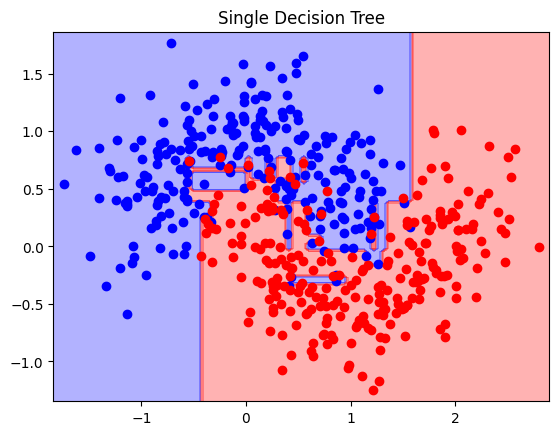

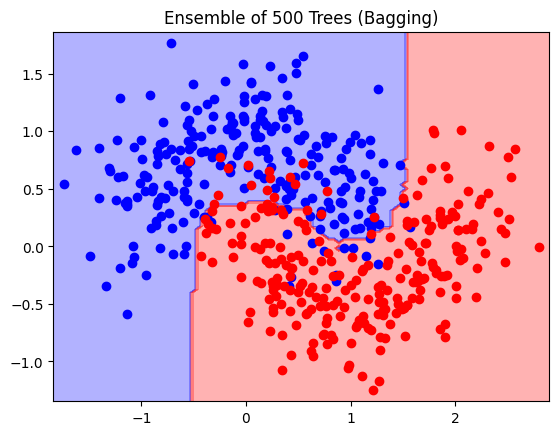

In [9]:
def plot_decision_tree(clf, X, y, title: str, axes = [-1, 1, -1, 1], plot_training: bool = True, configure_axes: bool = True) -> None:
    """Plots only two classes classification"""
    if configure_axes:
        axes[0], axes[1], axes[2], axes[3] = np.min(X[:, 0]) - 0.1, np.max(X[:, 0]) + 0.1, np.max(X[:, 1]) + 0.1, np.min(X[:, 1]) - 0.1

    X1s = np.linspace(axes[0], axes[1], 100)
    X2s = np.linspace(axes[2], axes[3], 100)

    x1, x2 = np.meshgrid(X1s, X2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=ListedColormap(["blue", "red"]))

    if plot_training:
        plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], c="blue")
        plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], c="red")

    plt.title(title)
    plt.show()

X_train, y_train = make_moons(500, noise=0.3, random_state=42)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)

plot_decision_tree(tree_clf, X_train, y_train, title="Single Decision Tree")
plot_decision_tree(bag_clf, X_train, y_train, title="Ensemble of 500 Trees (Bagging)")

## Out-of-Bag evaluation (OOB)

In [10]:
X, y = make_moons(500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [11]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

In [12]:
bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

## Random Forests

### Feature importance's

Since, decision trees in random forests are tending to lower split impurity, we can compute average impurity lowering for each feature. Then scale them, so they would sum up to 1.

In [54]:
X, y = fetch_openml('mnist_784', as_frame=False, return_X_y=True)
mnist_fores_clf = RandomForestClassifier(n_estimators=500, random_state=42, verbose=1, n_jobs=-1)
mnist_fores_clf.fit(X, y)

feature_importance = mnist_fores_clf.feature_importances_

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   13.3s finished


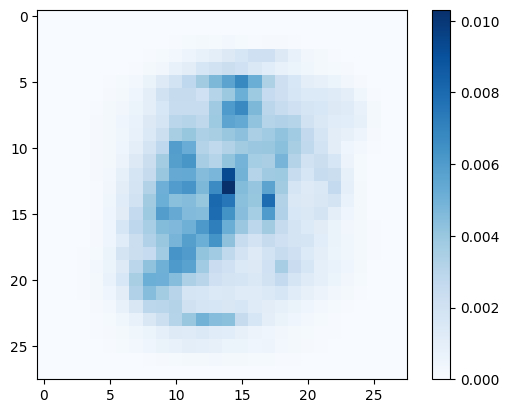

In [56]:
plt.imshow(feature_importance.reshape(28, 28), cmap="Blues")
plt.colorbar()
plt.show()